Nome: Letícia Lopes Mendes da Silva

RA: 184423

Curso: Eng. de Computação



# Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

In [ ]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist tensorboard

In [2]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision import transforms
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

%load_ext tensorboard

In [3]:
torch.set_float32_matmul_precision('medium')

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

#### 2.1.2) Preparação dos Dados

O código base abaixo foi utilizado para adquirir os dados do dataset, incluindo somente as classes "carcinoma basocelular" e "melanoma".

In [4]:
image_size = 28

class_names = ["carcinoma basocelular", "melanoma"]
class_mapping = {
    0: "carcinoma basocelular", # label original: 1
    1: "melanoma"               # label original: 4
}

train_dataset_base = DermaMNIST(
    split="train",
    download=True,
    size=image_size
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True,
    size=image_size
)

# Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])

# Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

# Labels
train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

# Formato dos dados
print(f"Train dataset: {train_imgs.shape}, {train_labels.shape}")
print(f"Validation dataset: {val_imgs.shape}, {val_labels.shape}")
print(f"Test dataset: {test_imgs.shape}, {test_labels.shape}")

# train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

# test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
# test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

Train dataset: (400, 28, 28, 3), (400,)
Validation dataset: (100, 28, 28, 3), (100,)
Test dataset: (100, 28, 28, 3), (100,)


##### Dataset

A partir dos dados obtidos, foi criada a classe `DermaMNISTBinaryDataset` para organizar as imagens e as labels no formato esperado para o código de treino. Isso facilitou a aquisição de amostras a partir da função `__getitem__`, que retorna uma tupla com a imagem e a label como tensores, aplicando transformações se forem especificadas.

In [5]:
class DermaMNISTBinaryDataset(Dataset):
    def __init__(self, split, transform=None):
        self.mode = split
        self.transform = transform
        self._load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = torch.tensor(self.data[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.int64)
        if self.transform:
            img = self.transform(img)
        return img, label

    def _load_data(self):
        if self.mode == "train":
            self.data = train_imgs
            self.labels = train_labels
        elif self.mode == "val":
            self.data = val_imgs
            self.labels = val_labels
        elif self.mode == "test":
            self.data = test_imgs
            self.labels = test_labels
        else:
            raise ValueError(f"Invalid mode {self.mode}")
        self.data = self.data.transpose(0, 3, 1, 2)   # Convertendo para shape (N, C, H, W)

Nesta atividade, foram utilizadas transformações com dois objetivos principais:

- **Aumentação de dados**: No conjunto de treino, foram aplicadas `RandomHorizontalFlip` e `RandomVerticalFlip` para gerar variações geométricas das lesões, e o `ColorJitter` (brilho, contraste e saturação) para gerar variações de intensidade de pixels, ajudando o modelo a aprender padrões de forma mais fácil e a reduzir overfitting.

- **Padronização do tipo de dado** Além disso, foi utilizada `ConvertImageDtype(torch.float32)` em treino, validação e teste para garantir consistência na entrada da rede e compatibilidade com as operações do PyTorch.

Além disso, como também foram experimentados modelos utilizando transfer learning com pesos treinados no ImageNet, as imagens foram normalizadas seguindo o padrão de treino neste dataset.

Como o conjunto é relativamente pequeno (400 imagens de treino), a estratégia de aumentação foi importante para melhorar a capacidade de generalização dos modelos.

In [6]:
data_transforms = {
    'train': transforms.Compose([
        # Transformações geométricas
        transforms.RandomHorizontalFlip(p=0.5), # Flip horizontal
        transforms.RandomVerticalFlip(p=0.5),   # Flip vertical
        # Transformação de intensidade
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # Variação de iluminação
        transforms.ConvertImageDtype(torch.float32),    # Garante que as imagens sejam float32
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalização ImageNet
    ]),
    'val': transforms.Compose([
        transforms.ConvertImageDtype(torch.float32),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.ConvertImageDtype(torch.float32),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

train_dataset = DermaMNISTBinaryDataset(split="train", transform=data_transforms["train"])
val_dataset   = DermaMNISTBinaryDataset(split="val",   transform=data_transforms["val"])
test_dataset  = DermaMNISTBinaryDataset(split="test",  transform=data_transforms["test"])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Train: 400 Val: 100 Test: 100


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8081232..1.1700488].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15266106..2.1632845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.565126..1.454815].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0126050515..1.5768193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9677871..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.28501397..1.5768193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.69986

2
<class 'torch.Tensor'> <class 'torch.Tensor'>
Imagem:
	Shape: torch.Size([3, 28, 28])
	Dtype: torch.float32
Label:
	Shape: torch.Size([])
	Dtype: torch.int64
	Valor: 0
Maior valor de intensidade da imagem: tensor(2.2147)
Menor valor de intensidade da imagem: tensor(-0.3230)


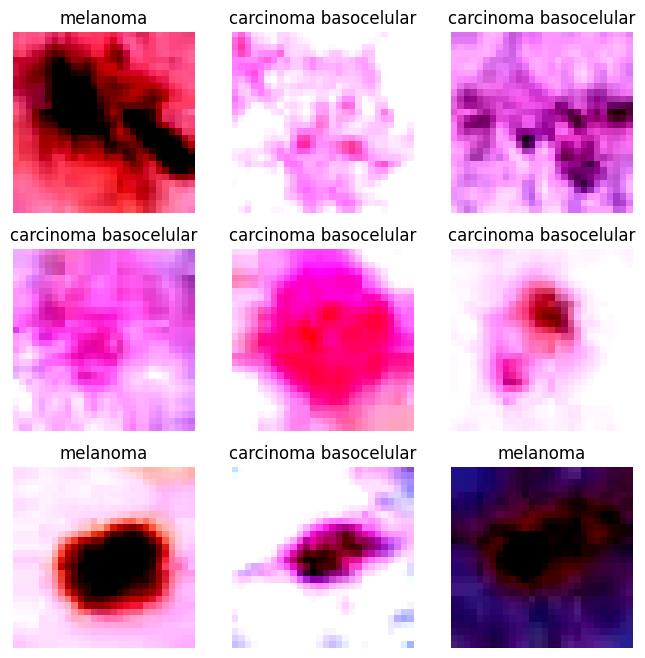

In [9]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(train_dataset)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print("Imagem:")
print(f"\tShape: {training_example[0].shape}")
print(f"\tDtype: {training_example[0].dtype}")
print(f"Label:")
print(f"\tShape: {training_example[1].shape}")
print(f"\tDtype: {training_example[1].dtype}")
print(f"\tValor: {training_example[1].item()}")
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(train_dataset)
    plt.subplot(rows, cols, i)
    plt.title(class_names[int(label)])
    plt.axis("off")
    # Convertendo o tensor para PIL Image para melhor visualização
    # A imagem é automaticamente convertida para uint8 e normalizada para o intervalo [0, 255]
    # img = F.to_pil_image(img, mode="RGB")
    if type(img) == torch.Tensor:
        # img = F.to_pil_image(img, mode="RGB")
        img = img.permute(1, 2, 0).numpy()  # Convertendo de (C, H, W) para (H, W, C)
    plt.imshow(img)
plt.show()

##### Lightning Data Module

Foi utilizada a classe `DermaMNISTDataModule` para centralizar a criação dos `DataLoaders` de treino, validação e teste. Essa organização facilita a manipulação dos dados e evita duplicação de código no treinamento e na avaliação.

In [10]:
class DermaMNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        if stage in ("fit", None):
            self.train = train_dataset
            self.val = val_dataset
        if stage in ("test", None):
            self.test = test_dataset

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Shape do batch: torch.Size([100, 3, 28, 28])
Shape do grid: torch.Size([3, 302, 302])


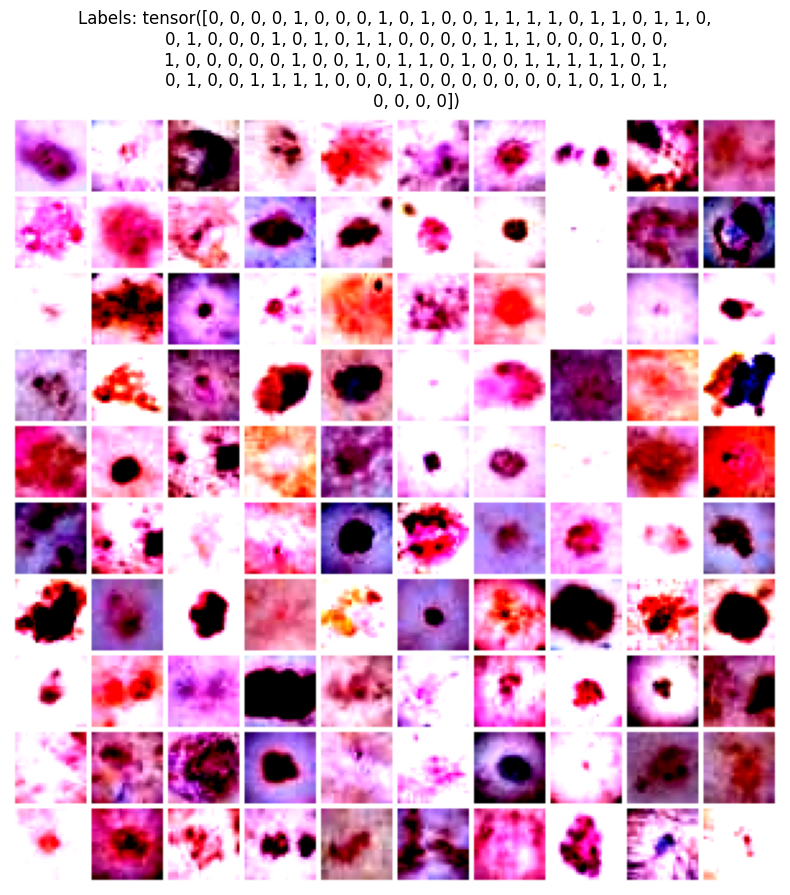

In [11]:
# DEBUG DATA MODULE
hparams = {
    "experiment_name": "Test_ResNet18_DermaMNIST",  # experiment name identifies the run for later
    "model_name": "resnet18",  # model architecture to use
    "weights": None,  # pretrained weights to use (None or False for no weights, or a string with the name of the weights)
    "max_epochs": 100,  # number of epochs to train
    "batch_size": 100,  # size of batch
    "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
    "nout": 2,  # number of classes
    "nin": 3,  # number of channels of the input image
    "lr": 1e-4,  # learning rate
    "wd": 1e-5,  # weight decay for optimizer
    "cpu": False,  # forces using the CPU
}

data_module = DermaMNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
print("Shape do grid:", img_grid.shape)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

#### 2.1.2) Definição do Classificador

##### Lightning Module

A classe `DermaMNISTBinaryClassifier` implementa o fluxo de treino/validação no PyTorch Lightning.

As principais decisões foram:
- uso de `CrossEntropyLoss`, adequada para classificação multiclasse no geral (aqui, 2 classes).
- métrica de acurácia para acompanhar desempenho em validação, o que é adequado para classificação binária.
- otimização com `AdamW`, combinando boa convergência com regularização via `learning_rate` e `weight_decay`.
- função `get_model` para permitir a troca de arquitetura (`resnet18`, `densenet`, `efficientnet`).

Também foi necessário adaptar as redes pré-definidas para o problema da atividade:
- camada de entrada ajustada para `nin=3` canais (imagens RGB).
- camada de saída ajustada para `nout=2` classes (carcinoma basocelular e melanoma).

Esse ajuste é essencial, pois os modelos carregados do Pytorch, por padrão, são configurados para ImageNet (1000 classes).

In [ ]:
class DermaMNISTBinaryClassifier(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = self.get_model()
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            # _, preds = torch.max(y_hat, 1)
            # self.accuracy(preds, y)
            self.accuracy(y_hat, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

    def get_model(self):
        AVAILABLE_MODELS = {
            "resnet18": models.resnet18,
            "resnet50": models.resnet50,
            "resnet101": models.resnet101,
            "densenet121": models.densenet121,
            "densenet169": models.densenet169,
            "efficientnet_b0": models.efficientnet_b0,
            "efficientnet_b4": models.efficientnet_b4,
        }

        weights = self.hparams.weights if hasattr(self.hparams, 'weights') else None
        weights = None if weights is False else weights
        name = self.hparams.model_name
        cnn = AVAILABLE_MODELS[name](weights=weights)

        if "resnet" in name:
            # Adaptando a primeira camada para o número de canais de entrada
            old_conv = cnn.conv1
            cnn.conv1 = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_conv.out_channels,
                kernel_size=old_conv.kernel_size,
                stride=old_conv.stride,
                padding=old_conv.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.fc.in_features
            cnn.fc = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        if "densenet" in name:
            # Adaptando a primeira camada para o número de canais de entrada
            old_features = cnn.features.conv0
            cnn.features.conv0 = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_features.out_channels,
                kernel_size=old_features.kernel_size,
                stride=old_features.stride,
                padding=old_features.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.classifier.in_features
            cnn.classifier = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        if "efficientnet" in name:
            # Adaptando a primeira camada para o número de canais de entrada
            old_features = cnn.features[0][0]
            cnn.features[0][0] = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_features.out_channels,
                kernel_size=old_features.kernel_size,
                stride=old_features.stride,
                padding=old_features.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.classifier[1].in_features
            cnn.classifier[1] = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        else:
            raise ValueError(f"Model {name} not available")

#### 2.1.3) Pipeline de Treino

In [13]:
def train_model(hparams, debug=False):
    # Initialization
    model = DermaMNISTBinaryClassifier(hparams)
    data = DermaMNISTDataModule(hparams)

    # The PL trainer can run various callbacks during training. Here we only use the
    # callback that saves the weights of the trained network.
    os.makedirs("logs", exist_ok=True)
    checkpoint_callback = ModelCheckpoint(
        dirpath="logs",  # path to save checkpoint
        filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
        monitor="val_acc",
        mode="max",
        verbose=True
    )

    # Early stopping callback to stop training if validation accuracy does not improve for 10 epochs
    # This is useful to prevent overfitting and save time during training
    early_stop_callback = EarlyStopping(
        monitor="val_acc",
        patience=10,
        mode="max",
        verbose=True
    )

    trainer = pl.Trainer(
        max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
        callbacks=[checkpoint_callback, early_stop_callback],
        log_every_n_steps=1,
        fast_dev_run=debug  # If debug=true, test the code with a quick run
    )

    print("Hyperparameters:\n")
    for k, v in hparams.items():
        print(f'{k}: {v}')

    summary(model, (hparams["nin"], image_size, image_size))

    trainer.fit(model, data)

#### 2.1.4) Pipeline de Avaliação

In [16]:
def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

def evaluate_model(ckpt_path):
    model = DermaMNISTBinaryClassifier.load_from_checkpoint(ckpt_path).eval().cuda()
    # Initialize test data
    data = DermaMNISTDataModule(hparams)
    data.setup()
    data.hparams.batch_size = 1
    test_data = data.test_dataloader()

    y_trues_val, y_labels_val = collect_2d_results(test_data, model)

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=[0, 1]),
                                    display_labels=class_names)
    fig = disp.plot(ax=None).figure_
    plt.show()

    # Classification report
    print(classification_report(y_trues_val, y_labels_val, target_names=class_names))

#### 2.1.5) Treinando CNNs

##### ResNet18

In [ ]:
train_model(hparams)

In [ ]:
%tensorboard --logdir lightning_logs

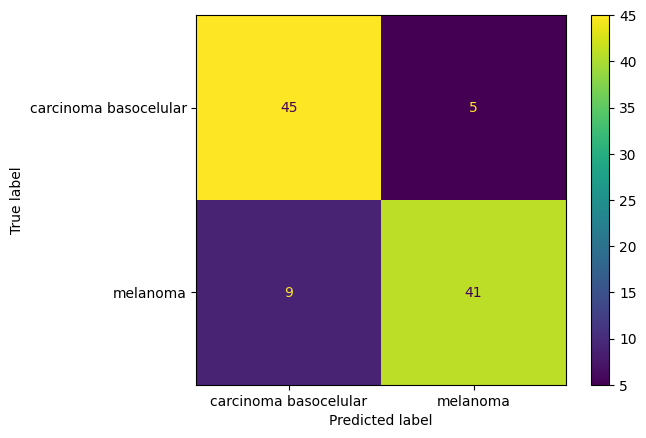

                       precision    recall  f1-score   support

carcinoma basocelular       0.83      0.90      0.87        50
             melanoma       0.89      0.82      0.85        50

             accuracy                           0.86       100
            macro avg       0.86      0.86      0.86       100
         weighted avg       0.86      0.86      0.86       100



In [42]:
baseline_model = "logs/Test_ResNet18_DermaMNIST-epoch=14-val_acc=0.90.ckpt"
evaluate_model(baseline_model)

##### ResNet50

In [ ]:
hparams["experiment_name"] = "Test_ResNet50_DermaMNIST"
hparams["model_name"] = "resnet50"
train_model(hparams)

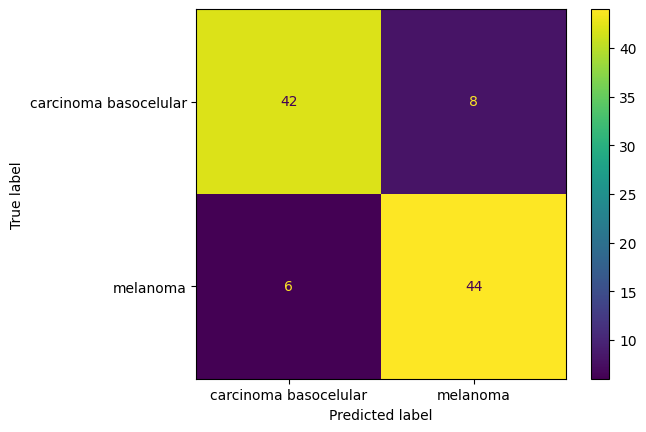

                       precision    recall  f1-score   support

carcinoma basocelular       0.88      0.84      0.86        50
             melanoma       0.85      0.88      0.86        50

             accuracy                           0.86       100
            macro avg       0.86      0.86      0.86       100
         weighted avg       0.86      0.86      0.86       100



In [36]:
baseline_model = "logs/Test_ResNet50_DermaMNIST-epoch=33-val_acc=0.86.ckpt"
evaluate_model(baseline_model)

##### ResNet101

In [ ]:
hparams["experiment_name"] = "Test_ResNet101_DermaMNIST"
hparams["model_name"] = "resnet101"
train_model(hparams)

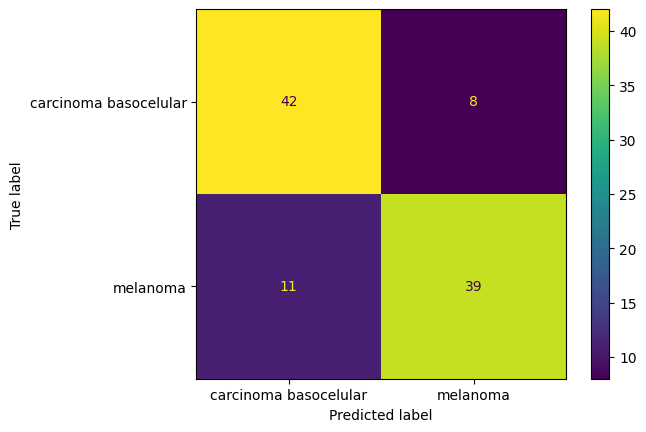

                       precision    recall  f1-score   support

carcinoma basocelular       0.79      0.84      0.82        50
             melanoma       0.83      0.78      0.80        50

             accuracy                           0.81       100
            macro avg       0.81      0.81      0.81       100
         weighted avg       0.81      0.81      0.81       100



In [68]:
baseline_model = "logs/Test_ResNet101_DermaMNIST-epoch=29-val_acc=0.82.ckpt"
evaluate_model(baseline_model)

##### ResNet18 com Transfer Learning

In [ ]:
hparams["experiment_name"] = "Test_ResNet18_pretrained_DermaMNIST"
hparams["model_name"] = "resnet18"
hparams["weights"] = "IMAGENET1K_V1"
train_model(hparams)

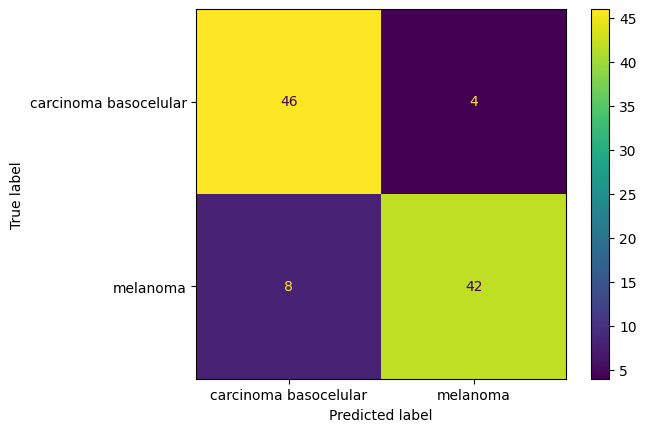

                       precision    recall  f1-score   support

carcinoma basocelular       0.85      0.92      0.88        50
             melanoma       0.91      0.84      0.88        50

             accuracy                           0.88       100
            macro avg       0.88      0.88      0.88       100
         weighted avg       0.88      0.88      0.88       100



In [17]:
baseline_model = "logs/Test_ResNet18_pretrained_DermaMNIST-epoch=25-val_acc=0.87.ckpt"
evaluate_model(baseline_model)

##### ResNet50 com Transfer Learning

In [ ]:
hparams["experiment_name"] = "Test_ResNet50_pretrained_DermaMNIST"
hparams["model_name"] = "resnet50"
hparams["weights"] = "IMAGENET1K_V1"
train_model(hparams)

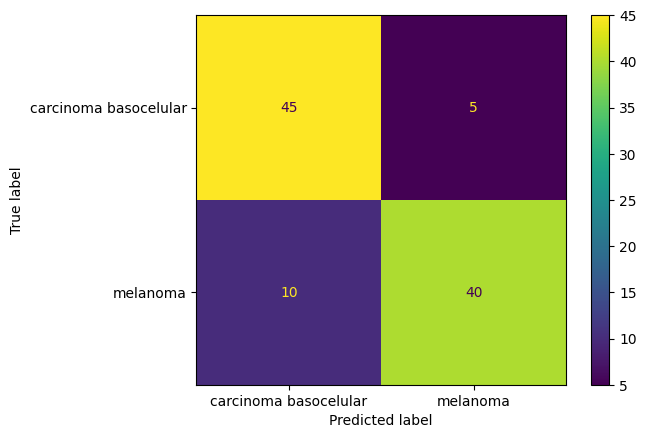

                       precision    recall  f1-score   support

carcinoma basocelular       0.82      0.90      0.86        50
             melanoma       0.89      0.80      0.84        50

             accuracy                           0.85       100
            macro avg       0.85      0.85      0.85       100
         weighted avg       0.85      0.85      0.85       100



In [23]:
baseline_model = "logs/Test_ResNet50_pretrained_DermaMNIST-epoch=13-val_acc=0.87.ckpt"
evaluate_model(baseline_model)

##### ResNet101 com Transfer Learning

In [ ]:
hparams["experiment_name"] = "Test_ResNet101_pretrained_DermaMNIST"
hparams["model_name"] = "resnet101"
hparams["weights"] = "IMAGENET1K_V1"
train_model(hparams)

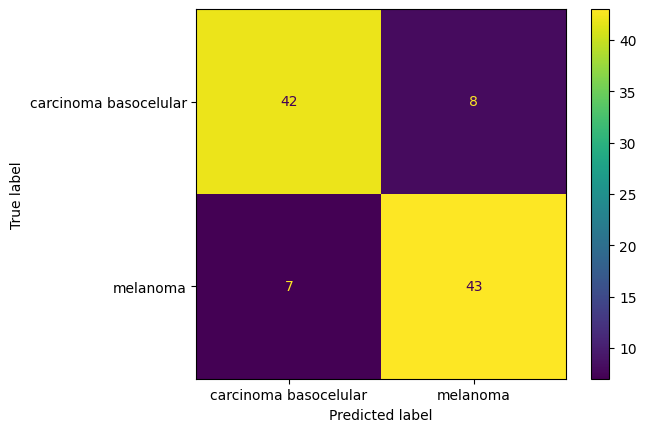

                       precision    recall  f1-score   support

carcinoma basocelular       0.86      0.84      0.85        50
             melanoma       0.84      0.86      0.85        50

             accuracy                           0.85       100
            macro avg       0.85      0.85      0.85       100
         weighted avg       0.85      0.85      0.85       100



In [25]:
baseline_model = "logs/Test_ResNet101_pretrained_DermaMNIST-epoch=21-val_acc=0.90.ckpt"
evaluate_model(baseline_model)

##### 2.1.5) Comentários sobre métodos e resultados

Foram avaliadas seis configurações de CNN (ResNet18, ResNet50 e ResNet101, com e sem transfer learning), mantendo o mesmo pipeline de dados, função de perda e otimizador para tornar a comparação mais consistente. Algumas variações de learning_rate, weight_decay e de otimizador foram testadas, mas a combinação atual resultou em desemepnhos satisfatórios, com rápida regularização. Além disso, modelos como DenseNet e EffcientNet não foram mostradas aqui devido ao seu baixo desempenho com imagens 28x28.

| Modelo | Acurácia |
|---|---:|
| ResNet18 | 0.86 |
| ResNet50 | 0.86 |
| ResNet101 | 0.81 |
| ResNet18 + ImageNet | **0.88** |
| ResNet50 + ImageNet | 0.85 |
| ResNet101 + ImageNet | 0.85 |

Dos resultados acima, vemos que a estratégia de transfer learning ajudou mais na ResNet18, que teve o melhor resultado geral. Modelos maiores (ResNet50 e ResNet101) não trouxeram ganho neste cenário, provavelmente pelo tamanho reduzido do dataset.

Comparação com o KNN (Exercício 02): Acurácia = 0.87.

Para comparação, foi utilizado o melhor modelo KNN treinado com seleção de atributos. Embora a ResNet18 tenha superado ligeiramente o KNN, seus resultados ainda são muito parecidos, o que pode favorecer o KNN por ser um modelo simples e rápido de treinar se comparado às CNNs. No entanto, ainda podem ser experimentadas outras abordagens para melhorar o desempenho das CNNs, como: testar mais estratégias de data augmentation, usar o dataset completo para treino, usar imagens maiores, seguindo o padrão ImageNet quando o transfer learning for aplicado (224x224) e testar outras arquiteturas mais robustas. Essas estratégias serão exploradas na próxima parte da atividade.